# VMR Protein Sequence Extraction Pipeline
## Extracting virus protein sequences from ICTV VMR for ML experiments

This notebook:
1. Downloads the latest VMR file
2. Extracts GenBank accessions
3. Fetches protein sequences via NCBI API
4. Prepares data for ESM-2 embeddings and ML experiments
5. Handles rate limiting and errors gracefully

## 1. Install Required Libraries

In [ ]:
# !pip install biopython pandas openpyxl requests tqdm
# 
# For ESM-2 later:
# !pip install fair-esm torch

In [1]:
pip install biopython pandas openpyxl requests tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 37.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [openpyxl]2/3 [openpyxl]]

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install certifi


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Import Libraries

In [3]:
import pandas as pd
import numpy as np
from Bio import Entrez, SeqIO
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq
import requests
import time
from pathlib import Path
from tqdm import tqdm
import certifi
import ssl
import warnings
from io import StringIO  # Add this line
warnings.filterwarnings('ignore')

# For saving intermediate results
import pickle
import json

## 3. Configuration

In [ ]:
# Use certifi for SSL verification
ssl_context = ssl.create_default_context(cafile=certifi.where())

# IMPORTANT: Set your email (required by NCBI)
Entrez.email = "example@example.com"  # CHANGE THIS!

# Optional: Get an API key from NCBI to increase rate limit from 3/sec to 10/sec
# https://www.ncbi.nlm.nih.gov/account/settings/
Entrez.api_key = "string API key"  # Set to your API key string if you have one

# Rate limiting
REQUEST_DELAY = 0.34 if Entrez.api_key is None else 0.11  # seconds between requests

# Paths
DATA_DIR = Path("vmr_data")
# DATA_DIR.mkdir(exist_ok=True)

# # VMR file URL (latest version as of April 2026)
# VMR_URL = "https://ictv.global/sites/default/files/VMR/VMR_MSL41.v1.20260320.xlsx"

## 4. Download VMR File

In [5]:
# def download_vmr(url, output_path):
#     """Download VMR file if not already present."""
#     if output_path.exists():
#         print(f"VMR file already exists at {output_path}")
#         return output_path
    
#     print(f"Downloading VMR file from {url}...")
#     response = requests.get(url, stream=True)
#     response.raise_for_status()
    
#     with open(output_path, 'wb') as f:
#         for chunk in response.iter_content(chunk_size=8192):
#             f.write(chunk)
    
#     print(f"Downloaded to {output_path}")
#     return output_path

vmr_path = DATA_DIR / "VMR_MSL41.v1.20260320.xlsx"
# download_vmr(VMR_URL, vmr_path)

## 5. Load and Explore VMR Data

In [6]:
# Read VMR file
# Note: VMR files typically have metadata rows at the top
# We'll need to identify the header row

# First, peek at the file structure
preview = pd.read_excel(vmr_path, nrows=10, sheet_name='VMR MSL41')
print("First 10 rows of VMR file:")
print(preview)

First 10 rows of VMR file:
   Isolate ID  Species Sort  Isolate Sort      Realm  Subrealm      Kingdom  \
0  VMR1028127             1             1  Adnaviria       NaN  Zilligvirae   
1  VMR1000002             2             1  Adnaviria       NaN  Zilligvirae   
2  VMR1000001             3             1  Adnaviria       NaN  Zilligvirae   
3  VMR1000003             4             1  Adnaviria       NaN  Zilligvirae   
4  VMR1000008             5             1  Adnaviria       NaN  Zilligvirae   
5  VMR1000005             6             1  Adnaviria       NaN  Zilligvirae   
6  VMR1000004             7             1  Adnaviria       NaN  Zilligvirae   
7  VMR1000006             8             1  Adnaviria       NaN  Zilligvirae   
8  VMR1000007             9             1  Adnaviria       NaN  Zilligvirae   
9  VMR1000010            10             1  Adnaviria       NaN  Zilligvirae   

   Subkingdom         Phylum  Subphylum          Class  ...        ICTV_ID  \
0         NaN  Taleaviric

In [7]:
# Typically the header is around row 5-7, adjust based on preview above
# Look for the row with columns like 'Sort', 'Realm', 'Kingdom', etc.
# header_row = 5  # ADJUST THIS based on what you see above

# vmr_df = pd.read_excel(vmr_path, header=header_row)

vmr_df = pd.read_excel(vmr_path, sheet_name='VMR MSL41')

print(f"\nLoaded VMR with {len(vmr_df)} entries")
print(f"\nColumn names:")
print(vmr_df.columns.tolist())


Loaded VMR with 19271 entries

Column names:
['Isolate ID', 'Species Sort', 'Isolate Sort', 'Realm', 'Subrealm', 'Kingdom', 'Subkingdom', 'Phylum', 'Subphylum', 'Class', 'Subclass', 'Order', 'Suborder', 'Family', 'Subfamily', 'Genus', 'Subgenus', 'Species', 'ICTV_ID', 'Exemplar or additional isolate', 'Virus name(s)', 'Virus name abbreviation(s)', 'Virus isolate designation', 'Virus GENBANK accession', 'Genome coverage', 'Genome', 'Host source', 'Accessions Link']


In [8]:
# Display basic statistics
print("\nVMR Data Summary:")
print(f"Total entries: {len(vmr_df)}")
print(f"\nColumns containing 'accession' or 'GenBank':")
accession_cols = [col for col in vmr_df.columns if 'accession' in str(col).lower() or 'genbank' in str(col).lower()]
print(accession_cols)

# Preview sample data
vmr_df.head()


VMR Data Summary:
Total entries: 19271

Columns containing 'accession' or 'GenBank':
['Virus GENBANK accession', 'Accessions Link']


,Isolate ID,Species Sort,Isolate Sort,Realm,Subrealm,Kingdom,Subkingdom,Phylum,Subphylum,Class,...,ICTV_ID,Exemplar or additional isolate,Virus name(s),Virus name abbreviation(s),Virus isolate designation,Virus GENBANK accession,Genome coverage,Genome,Host source,Accessions Link
0,VMR1028127,1,1,Adnaviria,NaN,Zilligvirae,NaN,Taleaviricota,NaN,Tokiviricetes,...,ICTV202420188,E,Bathyarchaeia bifangarchaeales chiyouvirus 1,BbCV1,NaN,PP467602,Complete genome,dsDNA,archaea,NCBI Nucleotide
1,VMR1000002,2,1,Adnaviria,NaN,Zilligvirae,NaN,Taleaviricota,NaN,Tokiviricetes,...,ICTV201908643,E,Sulfolobus filamentous virus 1,SFV1,S48,MH447526,Complete genome,dsDNA,archaea,NCBI Nucleotide
2,VMR1000001,3,1,Adnaviria,NaN,Zilligvirae,NaN,Taleaviricota,NaN,Tokiviricetes,...,ICTV201908644,E,Sulfolobales Beppu filamentous virus 2,SBFV2,clone B,MK064563,Coding-complete genome,dsDNA,archaea,NCBI Nucleotide
3,VMR1000003,4,1,Adnaviria,NaN,Zilligvirae,NaN,Taleaviricota,NaN,Tokiviricetes,...,ICTV20094000,E,Acidianus filamentous virus 3,AFV3,NaN,AM087120,Complete genome,dsDNA,archaea,NCBI Nucleotide
4,VMR1000008,5,1,Adnaviria,NaN,Zilligvirae,NaN,Taleaviricota,NaN,Tokiviricetes,...,ICTV20041365,E,Sulfolobus islandicus filamentous virus,SIFV,NaN,AF440571,Complete genome,dsDNA,archaea,NCBI Nucleotide


## 6. Identify and Extract GenBank Accessions

In [10]:
## 6. Identify and Extract GenBank Accessions (simplified filtering)

def is_valid_simple_accession(accession_str):
    """
    Check if accession is a simple, single GenBank ID.
    Simple rule: reject blanks and anything with spaces.
    
    Valid examples: OR713884, MN552442, NC_001806
    Invalid examples: 
        - RNA1: L00163; RNA2: X01572 (has spaces)
        - Seg1: KU984966; Seg2: KU984967 (has spaces)
        - [blank/NaN]
    """
    # Reject NaN/None
    if pd.isna(accession_str):
        return False
    
    accession_str = str(accession_str).strip()
    
    # Reject empty strings
    if not accession_str:
        return False
    
    # Reject anything with spaces (multi-segment entries have spaces)
    if ' ' in accession_str:
        return False
    
    return True


# Based on the column names above, identify the GenBank accession column
# ADJUST THIS based on actual column name from previous cell
GENBANK_COL = 'Virus GENBANK accession'  # or whatever the actual column name is

# Create a working copy
vmr_working = vmr_df.copy()

# Add validation column for debugging
vmr_working['is_valid_accession'] = vmr_working[GENBANK_COL].apply(is_valid_simple_accession)

# Show statistics before filtering
print("Accession Validation Statistics:")
print("=" * 60)
total_entries = len(vmr_working)
valid_count = vmr_working['is_valid_accession'].sum()
invalid_count = total_entries - valid_count

print(f"Total VMR entries: {total_entries}")
print(f"Valid single accessions: {valid_count} ({valid_count/total_entries*100:.1f}%)")
print(f"Invalid/multi-segment/blank: {invalid_count} ({invalid_count/total_entries*100:.1f}%)")

# Show examples of what's being filtered out
print("\n" + "=" * 60)
print("Examples of INVALID entries (will be dropped):")
print("=" * 60)
invalid_examples = vmr_working[~vmr_working['is_valid_accession']][GENBANK_COL].head(10)
for idx, example in enumerate(invalid_examples, 1):
    print(f"{idx}. {example}")

print("\n" + "=" * 60)
print("Examples of VALID entries (will be kept):")
print("=" * 60)
valid_examples = vmr_working[vmr_working['is_valid_accession']][GENBANK_COL].head(10)
for idx, example in enumerate(valid_examples, 1):
    print(f"{idx}. {example}")

# Filter to only valid entries
vmr_working = vmr_working[vmr_working['is_valid_accession']].copy()

# Drop the validation column (no longer needed)
vmr_working = vmr_working.drop('is_valid_accession', axis=1)

print("\n" + "=" * 60)
print(f"Final working dataset: {len(vmr_working)} entries")
print("=" * 60)

# Show sample of final data
print("\nSample accessions from filtered dataset:")
print(vmr_working[GENBANK_COL].head(10).tolist())

Accession Validation Statistics:
Total VMR entries: 19271
Valid single accessions: 16771 (87.0%)
Invalid/multi-segment/blank: 2500 (13.0%)

Examples of INVALID entries (will be dropped):
1. AE006468 (2844298.2877981)
2. nan
3. A: EU623082; B: EU623083
4. Seg1: OP436269; Seg2: OP436270
5. DNA-S.1: MF926436; DNA-S.2: MF926439; DNA-gamma: MF926441; DNA-R: MF926434
6. DNA-C: EF546812; DNA-M: EF546811; DNA-N: EF546808; DNA-R: EF546813; DNA-S: EF546810; DNA-U3: EF546809
7. DNA-C: EF546806; DNA-M: EF546805; DNA-N: EF546802; DNA-R: EF546807; DNA-S: EF546804; DNA-U3: EF546803
8. DNA-C: JX867548; DNA-M: JX569847; DNA-N: JX867546; DNA-R: JX867550; DNA-S: JX867540; DNA-U3: KF435143
9. DNA-C: KF711227; DNA-M: KF711064; DNA-N: KF711390; DNA-R: KF710575; DNA-S: KF710901; DNA-U3: KF710738
10. DNA-C: L41578; DNA-M: L41575; DNA-N: L41577; DNA-R: S56276; DNA-S: L41574; DNA-U3: L41576

Examples of VALID entries (will be kept):
1. PP467602
2. MH447526
3. MK064563
4. AM087120
5. AF440571
6. AM087122
7. AM08

## 7. Define Functions for Sequence Retrieval

In [11]:
## 8. Define Functions for Sequence Retrieval (using requests instead of Entrez)

def fetch_genbank_record(accession, max_retries=3):
    """
    Fetch a GenBank record using requests library (better SSL handling).
    
    Args:
        accession: GenBank accession number
        max_retries: Maximum number of retry attempts
    
    Returns:
        SeqRecord object or None if failed
    """
    for attempt in range(max_retries):
        try:
            time.sleep(REQUEST_DELAY)  # Rate limiting
            
            # Build NCBI efetch URL
            base_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi"
            params = {
                'db': 'nucleotide',
                'id': accession,
                'rettype': 'gb',
                'retmode': 'text'
            }
            
            # Add API key if available
            if Entrez.api_key:
                params['api_key'] = Entrez.api_key
            
            # Fetch using requests
            response = requests.get(base_url, params=params, timeout=30)
            response.raise_for_status()
            
            # Parse GenBank format
            from io import StringIO
            record = SeqIO.read(StringIO(response.text), "genbank")
            return record
            
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(2 ** attempt)  # Exponential backoff
            else:
                print(f"Failed to fetch {accession}: {str(e)}")
                return None
    return None


def extract_proteins_from_record(record, accession, virus_metadata):
    """
    Extract all protein sequences from a GenBank record.
    
    Args:
        record: SeqRecord object from GenBank
        accession: GenBank accession number
        virus_metadata: Dict with virus information from VMR
    
    Returns:
        List of dicts containing protein information
    """
    proteins = []
    
    for idx, feature in enumerate(record.features):
        if feature.type == "CDS":
            if "translation" in feature.qualifiers:
                protein_seq = feature.qualifiers["translation"][0]
                
                # Extract protein metadata
                protein_info = {
                    'accession': accession,
                    'protein_id': feature.qualifiers.get('protein_id', [f'unknown_{idx}'])[0],
                    'product': feature.qualifiers.get('product', ['Unknown'])[0],
                    'gene': feature.qualifiers.get('gene', [''])[0],
                    'sequence': protein_seq,
                    'sequence_length': len(protein_seq),
                    'location': str(feature.location),
                    'location_start': int(feature.location.start),
                    'location_end': int(feature.location.end),
                    'strand': feature.location.strand,
                }
                
                # Add virus metadata
                protein_info.update(virus_metadata)
                
                proteins.append(protein_info)
    
    return proteins


def create_virus_metadata(row):
    """
    Extract relevant virus metadata from VMR row.
    Uses actual VMR column names.
    """
    metadata = {
        # Identifiers
        'isolate_id': row.get('Isolate ID', ''),
        'ictv_id': row.get('ICTV_ID', ''),
        'virus_name': row.get('Virus name(s)', ''),
        'virus_abbrev': row.get('Virus name abbreviation(s)', ''),
        'isolate_designation': row.get('Virus isolate designation', ''),
        'exemplar_status': row.get('Exemplar or additional isolate', ''),
        
        # Taxonomy (all levels)
        'realm': row.get('Realm', ''),
        'subrealm': row.get('Subrealm', ''),
        'kingdom': row.get('Kingdom', ''),
        'subkingdom': row.get('Subkingdom', ''),
        'phylum': row.get('Phylum', ''),
        'subphylum': row.get('Subphylum', ''),
        'class': row.get('Class', ''),
        'subclass': row.get('Subclass', ''),
        'order': row.get('Order', ''),
        'suborder': row.get('Suborder', ''),
        'family': row.get('Family', ''),
        'subfamily': row.get('Subfamily', ''),
        'genus': row.get('Genus', ''),
        'subgenus': row.get('Subgenus', ''),
        'species': row.get('Species', ''),
        
        # Genome and host information
        'genome_type': row.get('Genome', ''),
        'genome_coverage': row.get('Genome coverage', ''),
        'host_source': row.get('Host source', ''),
    }
    return metadata

print("Functions defined successfully!")

Functions defined successfully!


## 8. Test Retrieval on Sample

In [12]:
# Test with first 5 entries
print("Testing with first 5 entries...\n")

test_results = []
for idx, row in vmr_working.head(5).iterrows():
    accession = row[GENBANK_COL]
    print(f"Fetching {accession}...")
    
    record = fetch_genbank_record(accession)
    if record:
        virus_metadata = create_virus_metadata(row)
        proteins = extract_proteins_from_record(record, accession, virus_metadata)
        test_results.extend(proteins)
        print(f"  → Found {len(proteins)} proteins")
    else:
        print(f"  → Failed to fetch")

# Display test results
if test_results:
    test_df = pd.DataFrame(test_results)
    print(f"\nTest extraction complete: {len(test_df)} proteins found")
    display(test_df.head())

Testing with first 5 entries...

Fetching PP467602...
  → Found 38 proteins
Fetching MH447526...
  → Found 66 proteins
Fetching MK064563...
  → Found 68 proteins
Fetching AM087120...
  → Found 68 proteins
Fetching AF440571...
  → Found 73 proteins

Test extraction complete: 313 proteins found


,accession,protein_id,product,gene,sequence,sequence_length,location,location_start,location_end,strand,...,order,suborder,family,subfamily,genus,subgenus,species,genome_type,genome_coverage,host_source
0,PP467602,WYC14516.1,DNA-binding protein,,MITTTRRGYIKVPPLQRERATAIMLYRAGQSINNIALFLGRSTSWV...,111,[175:511](-),175,511,-1,...,Ligamenvirales,NaN,Chiyouviridae,NaN,Wargodvirus,NaN,Wargodvirus xiongnu,dsDNA,Complete genome,archaea
1,PP467602,WYC14517.1,hypothetical protein,,MVYPHGLHIWERFKYSSMHTCTQAMSSQNLPGNKPRITVADGGGTP...,149,[646:1096](+),646,1096,1,...,Ligamenvirales,NaN,Chiyouviridae,NaN,Wargodvirus,NaN,Wargodvirus xiongnu,dsDNA,Complete genome,archaea
2,PP467602,WYC14518.1,hypothetical protein,,MKTFVAKEPFKVLSFYDKTVYYYVAFTHPYFYCIKITKRSDGSETA...,115,[1096:1444](+),1096,1444,1,...,Ligamenvirales,NaN,Chiyouviridae,NaN,Wargodvirus,NaN,Wargodvirus xiongnu,dsDNA,Complete genome,archaea
3,PP467602,WYC14519.1,hypothetical protein,,MSILTSLAHILYGFISALSITVHPVMPVLCLVLFIVYELDQEWHIS...,77,[1862:2096](-),1862,2096,-1,...,Ligamenvirales,NaN,Chiyouviridae,NaN,Wargodvirus,NaN,Wargodvirus xiongnu,dsDNA,Complete genome,archaea
4,PP467602,WYC14520.1,hypothetical protein,,MLKIIIPATLIIILLIVTLIGAAMLFSSAFSLLKTTGSLVEVGQAA...,78,[2161:2398](+),2161,2398,1,...,Ligamenvirales,NaN,Chiyouviridae,NaN,Wargodvirus,NaN,Wargodvirus xiongnu,dsDNA,Complete genome,archaea


## 9. Full Extraction Pipeline

**WARNING**: This will make many API calls. Start with a subset for testing!

In [13]:
# Choose how many entries to process
# Set to None to process all entries (this could take hours!)
NUM_ENTRIES_TO_PROCESS = None  # Start with 100, then increase

# Subset the data
if NUM_ENTRIES_TO_PROCESS:
    vmr_subset = vmr_working.head(NUM_ENTRIES_TO_PROCESS)
else:
    vmr_subset = vmr_working

print(f"Processing {len(vmr_subset)} entries...")
print(f"Estimated time: {len(vmr_subset) * REQUEST_DELAY / 60:.1f} minutes (minimum)\n")

Processing 16771 entries...
Estimated time: 30.7 minutes (minimum)



In [14]:
all_proteins = []
failed_accessions = []
success_count = 0
checkpoint_interval = 50  # Save progress every N entries

for idx, row in tqdm(vmr_subset.iterrows(), total=len(vmr_subset), desc="Fetching sequences"):
    accession = row[GENBANK_COL]
    
    # Fetch and process
    record = fetch_genbank_record(accession)
    
    if record:
        virus_metadata = create_virus_metadata(row)
        proteins = extract_proteins_from_record(record, accession, virus_metadata)
        all_proteins.extend(proteins)
        success_count += 1
    else:
        failed_accessions.append(accession)
    
    # Checkpoint: save intermediate results
    if (idx + 1) % checkpoint_interval == 0:
        temp_df = pd.DataFrame(all_proteins)
        temp_df.to_csv(DATA_DIR / f"checkpoint_{idx+1}.csv", index=False)
        print(f"\nCheckpoint saved at {idx+1} entries")

print(f"\n{'='*60}")
print(f"Extraction complete!")
print(f"Successfully processed: {success_count}/{len(vmr_subset)} entries")
print(f"Total proteins extracted: {len(all_proteins)}")
print(f"Failed accessions: {len(failed_accessions)}")

Fetching sequences:   0%|          | 0/16771 [00:00<?, ?it/s]

Fetching sequences:   0%|          | 50/16771 [00:21<2:11:24,  2.12it/s]


Checkpoint saved at 50 entries


Fetching sequences:   1%|          | 100/16771 [00:49<2:38:52,  1.75it/s]


Checkpoint saved at 100 entries


...


Checkpoint saved at 19200 entries


Fetching sequences: 100%|█████████▉| 16750/16771 [2:34:24<00:52,  2.48s/it]


Checkpoint saved at 19250 entries


Fetching sequences: 100%|██████████| 16771/16771 [2:34:32<00:00,  1.81it/s]


Extraction complete!
Successfully processed: 16768/16771 entries
Total proteins extracted: 778403
Failed accessions: 3


## 10. Create Final Dataset

In [15]:
# Convert to DataFrame
proteins_df = pd.DataFrame(all_proteins)

print(f"Final dataset shape: {proteins_df.shape}")
print(f"\nColumn names:")
print(proteins_df.columns.tolist())

# Basic statistics
print(f"\nDataset statistics:")
print(f"Total proteins: {len(proteins_df)}")
print(f"Unique viruses: {proteins_df['accession'].nunique()}")
print(f"Unique families: {proteins_df['family'].nunique()}")
print(f"Average sequence length: {proteins_df['sequence_length'].mean():.1f}")
print(f"Median sequence length: {proteins_df['sequence_length'].median():.1f}")

# Display sample
proteins_df.head()

Final dataset shape: (778403, 34)

Column names:
['accession', 'protein_id', 'product', 'gene', 'sequence', 'sequence_length', 'location', 'location_start', 'location_end', 'strand', 'isolate_id', 'ictv_id', 'virus_name', 'virus_abbrev', 'isolate_designation', 'exemplar_status', 'realm', 'subrealm', 'kingdom', 'subkingdom', 'phylum', 'subphylum', 'class', 'subclass', 'order', 'suborder', 'family', 'subfamily', 'genus', 'subgenus', 'species', 'genome_type', 'genome_coverage', 'host_source']

Dataset statistics:
Total proteins: 778403
Unique viruses: 15169
Unique families: 371
Average sequence length: 236.7
Median sequence length: 145.0


,accession,protein_id,product,gene,sequence,sequence_length,location,location_start,location_end,strand,...,order,suborder,family,subfamily,genus,subgenus,species,genome_type,genome_coverage,host_source
0,PP467602,WYC14516.1,DNA-binding protein,,MITTTRRGYIKVPPLQRERATAIMLYRAGQSINNIALFLGRSTSWV...,111,[175:511](-),175,511,-1.0,...,Ligamenvirales,NaN,Chiyouviridae,NaN,Wargodvirus,NaN,Wargodvirus xiongnu,dsDNA,Complete genome,archaea
1,PP467602,WYC14517.1,hypothetical protein,,MVYPHGLHIWERFKYSSMHTCTQAMSSQNLPGNKPRITVADGGGTP...,149,[646:1096](+),646,1096,1.0,...,Ligamenvirales,NaN,Chiyouviridae,NaN,Wargodvirus,NaN,Wargodvirus xiongnu,dsDNA,Complete genome,archaea
2,PP467602,WYC14518.1,hypothetical protein,,MKTFVAKEPFKVLSFYDKTVYYYVAFTHPYFYCIKITKRSDGSETA...,115,[1096:1444](+),1096,1444,1.0,...,Ligamenvirales,NaN,Chiyouviridae,NaN,Wargodvirus,NaN,Wargodvirus xiongnu,dsDNA,Complete genome,archaea
3,PP467602,WYC14519.1,hypothetical protein,,MSILTSLAHILYGFISALSITVHPVMPVLCLVLFIVYELDQEWHIS...,77,[1862:2096](-),1862,2096,-1.0,...,Ligamenvirales,NaN,Chiyouviridae,NaN,Wargodvirus,NaN,Wargodvirus xiongnu,dsDNA,Complete genome,archaea
4,PP467602,WYC14520.1,hypothetical protein,,MLKIIIPATLIIILLIVTLIGAAMLFSSAFSLLKTTGSLVEVGQAA...,78,[2161:2398](+),2161,2398,1.0,...,Ligamenvirales,NaN,Chiyouviridae,NaN,Wargodvirus,NaN,Wargodvirus xiongnu,dsDNA,Complete genome,archaea


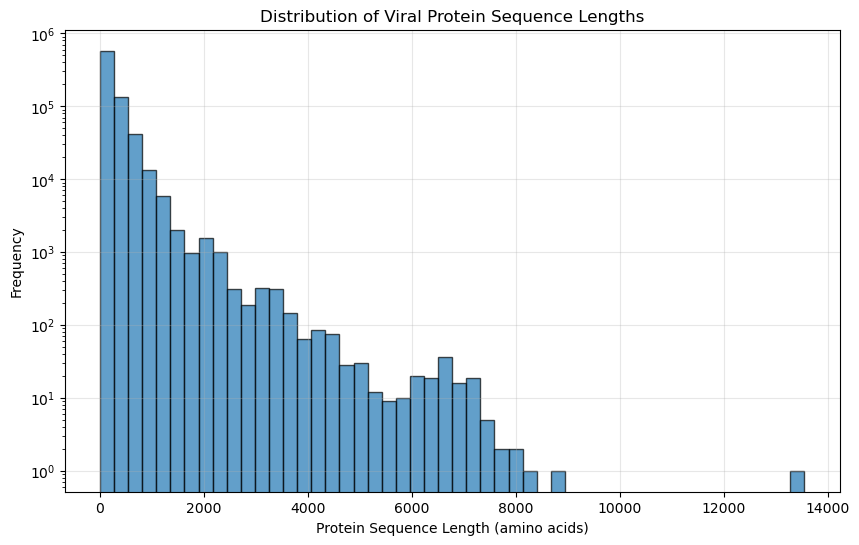


Top 10 most common protein products:
product
hypothetical protein              446904
minor tail protein                  5524
unknown                             3765
major capsid protein                3305
HNH endonuclease                    3047
terminase large subunit             3012
portal protein                      2946
Unknown                             2748
conserved hypothetical protein      2346
Hypothetical protein                2257
Name: count, dtype: int64


In [16]:
# Sequence length distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(proteins_df['sequence_length'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Protein Sequence Length (amino acids)')
plt.ylabel('Frequency')
plt.title('Distribution of Viral Protein Sequence Lengths')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

# Top protein products
print("\nTop 10 most common protein products:")
print(proteins_df['product'].value_counts().head(10))

## 11. Save Results in Multiple Formats

In [17]:
# 1. Save as CSV (good for pandas/general use)
csv_path = DATA_DIR / "virus_proteins.csv"
proteins_df.to_csv(csv_path, index=False)
print(f"Saved CSV to: {csv_path}")

# 2. Save as Parquet (efficient, preserves dtypes)
parquet_path = DATA_DIR / "virus_proteins.parquet"
proteins_df.to_parquet(parquet_path, index=False)
print(f"Saved Parquet to: {parquet_path}")

# 3. Save as FASTA (for sequence analysis tools)
fasta_path = DATA_DIR / "virus_proteins.fasta"
with open(fasta_path, 'w') as f:
    for _, row in proteins_df.iterrows():
        # Create descriptive header
        header = f">{row['protein_id']}|{row['accession']}|{row['product']}|{row['virus_name']}"
        f.write(f"{header}\n")
        f.write(f"{row['sequence']}\n")
print(f"Saved FASTA to: {fasta_path}")

# 4. Save failed accessions for reference
if failed_accessions:
    failed_path = DATA_DIR / "failed_accessions.txt"
    with open(failed_path, 'w') as f:
        f.write("\n".join(failed_accessions))
    print(f"Saved failed accessions to: {failed_path}")

# 5. Save metadata summary
metadata_summary = {
    'total_proteins': len(proteins_df),
    'unique_viruses': proteins_df['accession'].nunique(),
    'unique_families': proteins_df['family'].nunique(),
    'unique_genera': proteins_df['genus'].nunique(),
    'processing_date': pd.Timestamp.now().isoformat(),
    'vmr_file': str(vmr_path),
    'failed_accessions': len(failed_accessions)
}

with open(DATA_DIR / "metadata_summary.json", 'w') as f:
    json.dump(metadata_summary, f, indent=2)

print("\nAll files saved successfully!")

Saved CSV to: vmr_data/virus_proteins.csv
Saved Parquet to: vmr_data/virus_proteins.parquet
Saved FASTA to: vmr_data/virus_proteins.fasta
Saved failed accessions to: vmr_data/failed_accessions.txt

All files saved successfully!


## 12. Prepare Data for ESM-2 Embeddings

In [18]:
# ESM-2 expects sequences in a specific format
# Let's create a clean dataset for embedding generation

# Filter out very long sequences (ESM-2 has token limits)
MAX_SEQ_LENGTH = 1024  # ESM-2 650M can handle up to 1024 tokens

esm_ready_df = proteins_df[proteins_df['sequence_length'] <= MAX_SEQ_LENGTH].copy()

print(f"Sequences ready for ESM-2: {len(esm_ready_df)}/{len(proteins_df)}")
print(f"Filtered out {len(proteins_df) - len(esm_ready_df)} sequences longer than {MAX_SEQ_LENGTH} aa")

# Save ESM-2 ready dataset
esm_csv_path = DATA_DIR / "virus_proteins_esm2_ready.csv"
esm_ready_df.to_csv(esm_csv_path, index=False)

esm_fasta_path = DATA_DIR / "virus_proteins_esm2_ready.fasta"
with open(esm_fasta_path, 'w') as f:
    for _, row in esm_ready_df.iterrows():
        header = f">{row['protein_id']}|{row['accession']}"
        f.write(f"{header}\n")
        f.write(f"{row['sequence']}\n")

print(f"\nESM-2 ready files saved:")
print(f"  CSV: {esm_csv_path}")
print(f"  FASTA: {esm_fasta_path}")

Sequences ready for ESM-2: 763548/778403
Filtered out 14855 sequences longer than 1024 aa

ESM-2 ready files saved:
  CSV: vmr_data/virus_proteins_esm2_ready.csv
  FASTA: vmr_data/virus_proteins_esm2_ready.fasta


## 13. Data Quality Checks

In [20]:
print("Data Quality Report")
print("=" * 60)

# Check for missing values
print("\nMissing values per column:")
missing = proteins_df.isnull().sum()
print(missing[missing > 0])

# Check for duplicate protein IDs
duplicates = proteins_df['protein_id'].duplicated().sum()
print(f"\nDuplicate protein IDs: {duplicates}")

# Check sequence validity (all amino acids should be valid)
valid_aa = set('ACDEFGHIKLMNPQRSTVWY')
invalid_sequences = []

for idx, seq in enumerate(proteins_df['sequence'].head(100)):  # Check first 100
    if not set(seq.upper()).issubset(valid_aa):
        invalid_sequences.append(idx)

print(f"\nInvalid sequences in sample: {len(invalid_sequences)}")

# Taxonomy coverage
print("\nTaxonomy coverage:")
print(f"Realms: {proteins_df['realm'].nunique()}")
print(f"Kingdoms: {proteins_df['kingdom'].nunique()}")
print(f"Phyla: {proteins_df['phylum'].nunique()}")
print(f"Classes: {proteins_df['class'].nunique()}")
print(f"Orders: {proteins_df['order'].nunique()}")
print(f"Families: {proteins_df['family'].nunique()}")
print(f"Genera: {proteins_df['genus'].nunique()}")
print(f"Species: {proteins_df['species'].nunique()}")

Data Quality Report

Missing values per column:
strand                      2
virus_name                  5
virus_abbrev           627746
isolate_designation    679702
realm                   25335
subrealm               778403
kingdom                 25374
subkingdom             778403
phylum                  25376
subphylum              764458
class                    2413
subclass               778403
order                  483577
suborder               745517
family                 233278
subfamily              359032
subgenus               768502
genome_coverage            40
dtype: int64

Duplicate protein IDs: 0

Invalid sequences in sample: 0

Taxonomy coverage:
Realms: 10
Kingdoms: 11
Phyla: 21
Classes: 41
Orders: 93
Families: 371
Genera: 3651
Species: 13947


## 15. Summary and Next Steps

In [1]:
print("""
╔════════════════════════════════════════════════════════════╗
║           VMR SEQUENCE EXTRACTION COMPLETE                 ║
╚════════════════════════════════════════════════════════════╝

Files created:
  • virus_proteins.csv - Full dataset in CSV format
  • virus_proteins.parquet - Efficient binary format
  • virus_proteins.fasta - FASTA format for sequence tools
  • virus_proteins_esm2_ready.csv - Filtered for ESM-2
  • virus_proteins_esm2_ready.fasta - FASTA for ESM-2
  • metadata_summary.json - Processing metadata
""")

print(f"\nAll data saved in: {DATA_DIR.absolute()}")


╔════════════════════════════════════════════════════════════╗
║           VMR SEQUENCE EXTRACTION COMPLETE                 ║
╚════════════════════════════════════════════════════════════╝

Files created:
  • virus_proteins.csv - Full dataset in CSV format
  • virus_proteins.parquet - Efficient binary format
  • virus_proteins.fasta - FASTA format for sequence tools
  • virus_proteins_esm2_ready.csv - Filtered for ESM-2
  • virus_proteins_esm2_ready.fasta - FASTA for ESM-2
  • metadata_summary.json - Processing metadata



NameError: name 'DATA_DIR' is not defined